<a href="https://colab.research.google.com/github/alexandrustancluj/2026/blob/main/Lab_7_8_OOP_Pyhton_for_Quant_Extended.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lab 7–8

## Object-Oriented Programming Lab with Quant Examples

It is an OOP lab with with quant-oriented examples.



## Outline

1. Classes and objects

2. Constructors

3. Instance methods

4. Exceptions and validation

5. Properties

6. Static members

7. Static methods and class methods

8. Composition and aggregation

9. Inheritance and method overriding

10. Abstract classes

11. Quant examples with positions portfolios returns and risk checks

12. Integrated mini-project


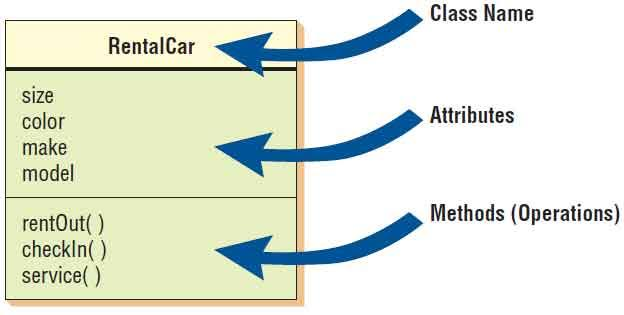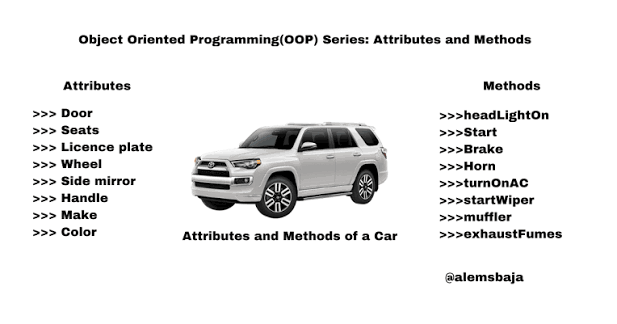

## Classes and objects

A class is a blueprint. An object is created from a class. Objects combine data and behavior.


In [32]:
class Student:
    pass

student = Student()
student.name = "Ana"
student.grade = 9

print(student.name)
print(student.grade)


Ana
9


## Constructors

A constructor initializes a new object. In Python the constructor method is called `__init__`.


In [33]:
class Student:
    def __init__(self, name, grade):
        self.name = name
        self.grade = grade

student = Student("Ana", 9)

print(student.name)
print(student.grade)


Ana
9


## Instance methods

An instance method belongs to an object. It can access the object through `self`.


In [34]:
class Student:
    def __init__(self, name, grade):
        self.name = name
        self.grade = grade

    def status(self):
        if self.grade >= 5:
            return "passed"
        return "failed"

student = Student("Ana", 9)

print(student.status())


passed


## First quant class: Asset

An asset has a ticker and a price. A method can produce a short description.


In [35]:
class Asset:
    def __init__(self, ticker, price):
        self.ticker = ticker
        self.price = price

    def description(self):
        return f"{self.ticker} has price {self.price:.2f}"

asset = Asset("AAPL", 190.25)

print(asset.description())


AAPL has price 190.25


## Position class

A position combines a ticker with shares and price. The market value is computed by a method.


In [37]:
class Position:
    def __init__(self, ticker, shares, price):
        self.ticker = ticker
        self.shares = shares
        self.price = price

    def market_value(self):
        return self.shares * self.price

position = Position("AAPL", 10, 190.25)

print(f"Market value: {position.market_value():.2f}")


Market value: 1902.50


## Profit and loss

A method can compute a derived value. The profit or loss depends on the buy price and current price.


In [38]:
class Position:
    def __init__(self, ticker, shares, buy_price, current_price):
        self.ticker = ticker
        self.shares = shares
        self.buy_price = buy_price
        self.current_price = current_price

    def market_value(self):
        return self.shares * self.current_price

    def profit_loss(self):
        return self.shares * (self.current_price - self.buy_price)

    def return_rate(self):
        return self.current_price / self.buy_price - 1

position = Position("MSFT", 5, 390.00, 420.10)

print(f"Market value: {position.market_value():.2f}")
print(f"Profit or loss: {position.profit_loss():.2f}")
print(f"Return: {position.return_rate():.2%}")


Market value: 2100.50
Profit or loss: 150.50
Return: 7.72%


## Exceptions for invalid objects

A constructor can reject invalid inputs. This prevents invalid objects from being created.


In [39]:
class Position:
    def __init__(self, ticker, shares, buy_price, current_price):
        if shares < 0:
            raise ValueError("Shares cannot be negative.")
        if buy_price <= 0:
            raise ValueError("Buy price must be positive.")
        if current_price <= 0:
            raise ValueError("Current price must be positive.")

        self.ticker = ticker
        self.shares = shares
        self.buy_price = buy_price
        self.current_price = current_price

try:
    position = Position("AAPL", 10, -180.00, 190.25)
except ValueError as error:
    print(error)


Buy price must be positive.


## Properties

A property controls access to an attribute. It can validate a value before storing it.


In [42]:
class Position:
    def __init__(self, ticker, shares, price):
        self.ticker = ticker
        self.shares = shares
        self.price = price

    @property
    def shares(self):
        return self._shares

    @shares.setter
    def shares(self, value):
        if value < 0:
            raise ValueError("Shares cannot be negative.")
        self._shares = value

    @property
    def price(self):
        return self._price

    @price.setter
    def price(self, value):
        #breakpoint()
        if value <= 0:
            raise ValueError("Price must be positive.")
        self._price = value

    def market_value(self):
        return self.shares * self.price

position = Position("AAPL", 10, 190.25)

print(position.market_value())

try:
    position.price = -5
except ValueError as error:
    print(error)


1902.5
Price must be positive.


## Read-only computed properties

A property can compute a value. The value is read like an attribute.


In [43]:
class Position:
    def __init__(self, ticker, shares, buy_price, current_price):
        self.ticker = ticker
        self.shares = shares
        self.buy_price = buy_price
        self.current_price = current_price

    @property
    def market_value(self):
        return self.shares * self.current_price

    @property
    def profit_loss(self):
        return self.shares * (self.current_price - self.buy_price)

    @property
    def return_rate(self):
        return self.current_price / self.buy_price - 1

position = Position("GOOG", 12, 130.00, 135.80)

print(f"Market value: {position.market_value:.2f}")
print(f"Profit or loss: {position.profit_loss:.2f}")
print(f"Return: {position.return_rate:.2%}")


Market value: 1629.60
Profit or loss: 69.60
Return: 4.46%


## String representation

The method `__repr__` defines how an object appears when printed.


In [47]:
class Position:
    def __init__(self, ticker, shares, price):
        self.ticker = ticker
        self.shares = shares
        self.price = price

    def market_value(self):
        return self.shares * self.price

    def __repr__(self):
        return f"Position(ticker={self.ticker!r}, shares={self.shares}, price={self.price})"

position = Position("AAPL", 10, 190.25)

print(str(position) + " in dollars")


Position(ticker='AAPL', shares=10, price=190.25) in dollars


## Static members

A class attribute belongs to the class. It is shared by all objects of that class.


In [48]:
class Position:
    currency = "USD"

    def __init__(self, ticker, shares, price):
        self.ticker = ticker
        self.shares = shares
        self.price = price

    def market_value(self):
        return self.shares * self.price

position_1 = Position("AAPL", 10, 190.25)
position_2 = Position("MSFT", 5, 420.10)

print(position_1.currency)
print(position_2.currency)
print(Position.currency)


USD
USD
USD


## Counting created objects

A class attribute can track shared information. Here it counts created positions.


In [50]:
class Position:
    number_of_positions = 0

    def __init__(self, ticker, shares, price):
        self.ticker = ticker
        self.shares = shares
        self.price = price
        Position.number_of_positions += 1

p1 = Position("AAPL", 10, 190.25)
p2 = Position("MSFT", 5, 420.10)
p3 = Position("GOOG", 8, 135.80)

print(Position.number_of_positions)


3


## Static methods

A static method is a helper function placed inside a class namespace.


In [52]:
class FinanceUtils:
    @staticmethod
    def simple_return(initial_price, final_price):
        if initial_price <= 0:
            raise ValueError("Initial price must be positive.")
        return final_price / initial_price - 1

result = FinanceUtils.simple_return(100, 108)

print(f"Return: {result:.2%}")


Return: 8.00%


## Class methods

A class method receives the class as `cls`. It is often used as an alternative constructor.


In [53]:
class Position:
    def __init__(self, ticker, shares, price):
        self.ticker = ticker
        self.shares = shares
        self.price = price

    @classmethod
    def from_text(cls, text):
        ticker, shares, price = text.split(",")
        return cls(ticker.strip(), int(shares), float(price))

position = Position.from_text("    AAPL    , 10, 190.25")

print(position.ticker)
print(position.shares)
print(position.price)


AAPL
10
190.25


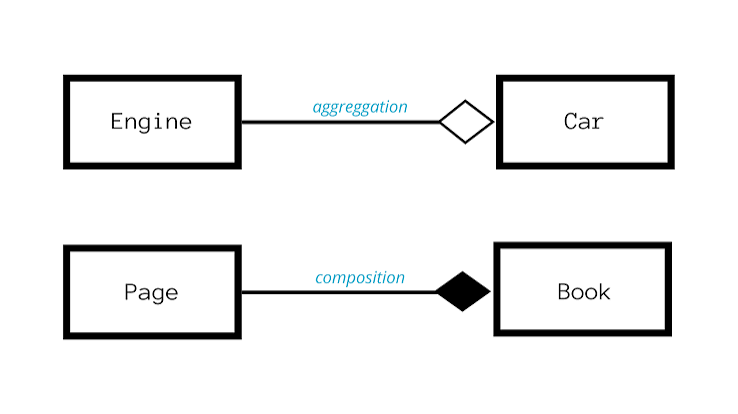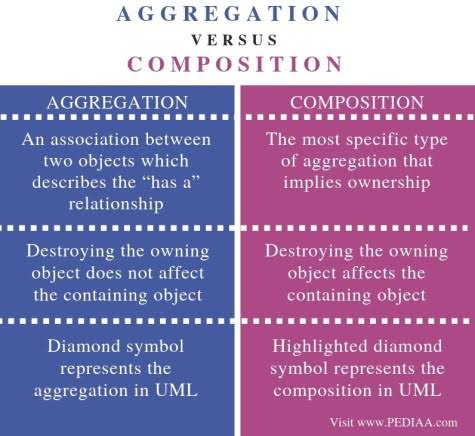

## Composition

Composition means that one object contains another object as an essential part.


In [ ]:
class Asset:
    def __init__(self, ticker, sector):
        self.ticker = ticker
        self.sector = sector

class Position:
    def __init__(self, ticker, sector, shares, price):
        self.asset = Asset(ticker, sector)
        self.shares = shares
        self.price = price

    def market_value(self):
        return self.shares * self.price

position = Position("AAPL", "Technology", 10, 190.25)

print(position.asset.ticker)
print(position.asset.sector)
print(position.market_value())


## Aggregation

Aggregation connects objects that can exist independently. A portfolio aggregates positions.


In [54]:
class Position:
    def __init__(self, ticker, shares, price):
        self.ticker = ticker
        self.shares = shares
        self.price = price

    def market_value(self):
        return self.shares * self.price

class Portfolio:
    def __init__(self, name):
        self.name = name
        self.positions = []

    def add_position(self, position):
        self.positions.append(position)

    def total_value(self):
        return sum(position.market_value() for position in self.positions)

position_1 = Position("AAPL", 10, 190.25)
position_2 = Position("MSFT", 5, 420.10)

portfolio = Portfolio("Growth Portfolio")
portfolio.add_position(position_1)
portfolio.add_position(position_2)

print(f"Portfolio value: {portfolio.total_value():.2f}")


Portfolio value: 4003.00


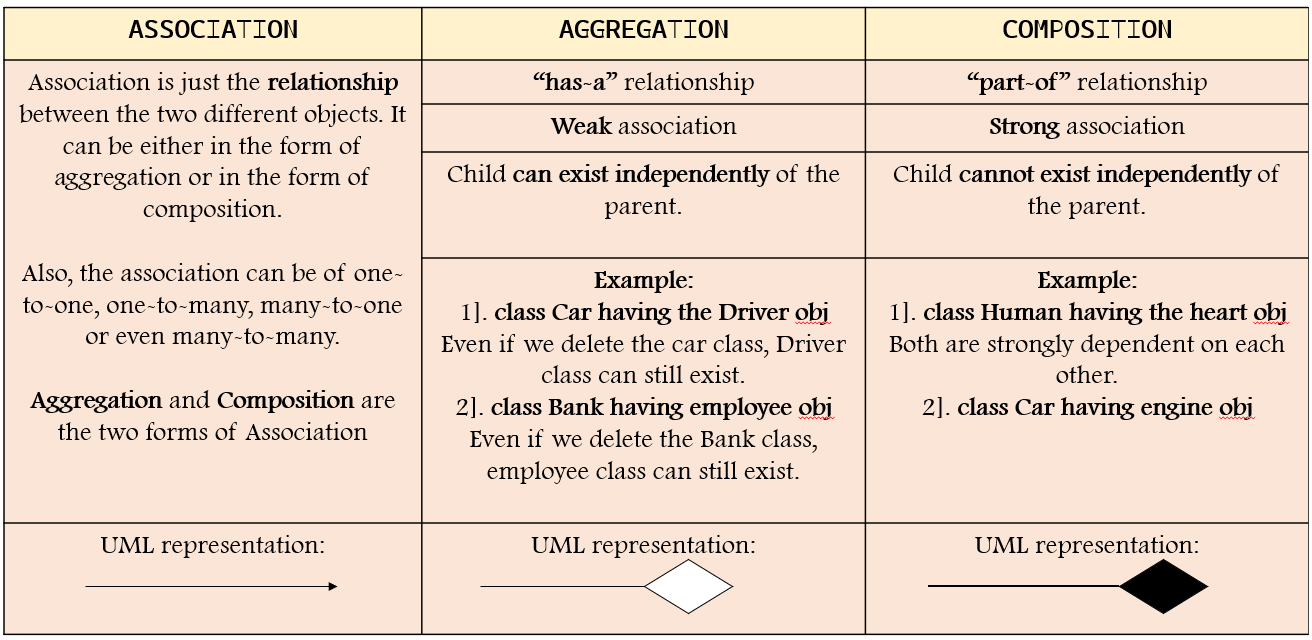

## Portfolio report

The portfolio can print a report. Each position computes its own market value.


In [55]:
class Portfolio:
    def __init__(self, name):
        self.name = name
        self.positions = []

    def add_position(self, position):
        self.positions.append(position)

    def total_value(self):
        return sum(position.market_value() for position in self.positions)

    def report(self):
        print(self.name)
        print("-" * len(self.name))

        for position in self.positions:
            print(f"{position.ticker}: {position.market_value():.2f}")

        print(f"Total: {self.total_value():.2f}")

portfolio = Portfolio("Growth Portfolio")
portfolio.add_position(Position("AAPL", 10, 190.25))
portfolio.add_position(Position("MSFT", 5, 420.10))
portfolio.add_position(Position("GOOG", 8, 135.80))

portfolio.report()


Growth Portfolio
----------------
AAPL: 1902.50
MSFT: 2100.50
GOOG: 1086.40
Total: 5089.40


## Portfolio weights

A portfolio weight is the position value divided by total value.


In [56]:
class Portfolio:
    def __init__(self, name):
        self.name = name
        self.positions = []

    def add_position(self, position):
        self.positions.append(position)

    def total_value(self):
        return sum(position.market_value() for position in self.positions)

    def weights(self):
        total = self.total_value()
        return {
            position.ticker: position.market_value() / total
            for position in self.positions
        }

portfolio = Portfolio("Growth Portfolio")
portfolio.add_position(Position("AAPL", 10, 190.25))
portfolio.add_position(Position("MSFT", 5, 420.10))
portfolio.add_position(Position("GOOG", 8, 135.80))

print(portfolio.weights())


{'AAPL': 0.3738161669351987, 'MSFT': 0.4127205564506622, 'GOOG': 0.21346327661413922}


## Risk limit check

A portfolio can check whether an asset weight is too large.


In [60]:
class Portfolio:
    def __init__(self, name):
        self.name = name
        self.positions = []

    def add_position(self, position):
        self.positions.append(position)

    def total_value(self):
        return sum(position.market_value() for position in self.positions)

    def weights(self):
        total = self.total_value()
        return {
            position.ticker: position.market_value() / total
            for position in self.positions
        }

    def positions_above_limit(self, limit):
        return {
            ticker: weight
            for ticker, weight in self.weights().items()
            if weight > limit
        }

portfolio = Portfolio("Concentrated Portfolio")
portfolio.add_position(Position("AAPL", 30, 190.25))
portfolio.add_position(Position("MSFT", 2, 420.10))
portfolio.add_position(Position("GOOG", 2, 135.80))

print(portfolio.positions_above_limit(0.20))


{'AAPL': 0.8369627381109498}


## Inheritance

Inheritance allows a class to reuse another class. The derived class inherits methods and attributes.


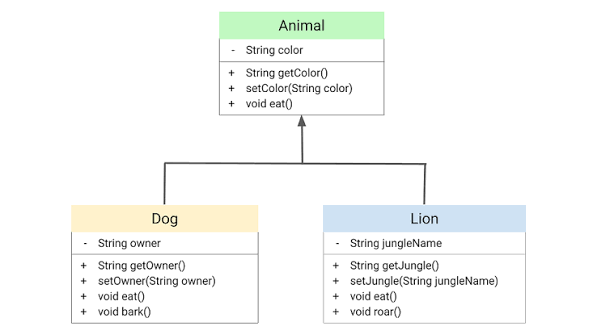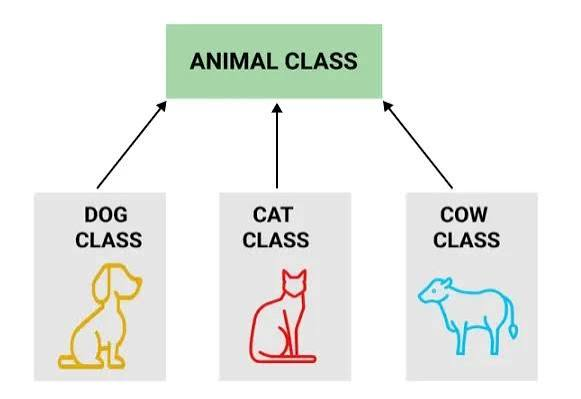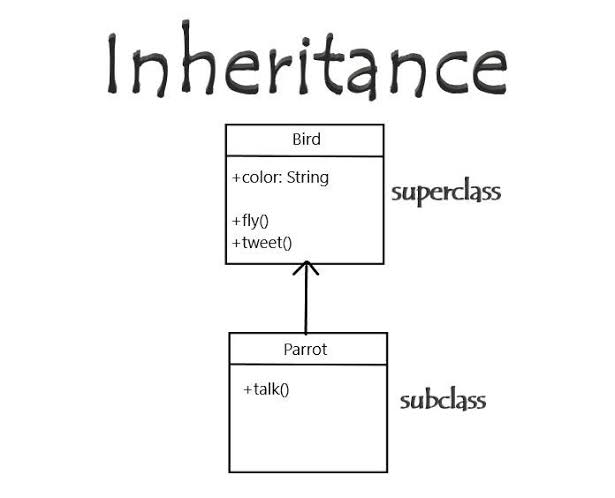

In [61]:
class Asset:
    def __init__(self, ticker, price):
        self.ticker = ticker
        self.price = price

    def description(self):
        return f"{self.ticker} at price {self.price:.2f}"

class Stock(Asset):
    def __init__(self, ticker, price, exchange):
        super().__init__(ticker, price)
        self.exchange = exchange

stock = Stock("AAPL", 190.25, "NASDAQ")

print(stock.description())
print(stock.exchange)


AAPL at price 190.25
NASDAQ


## Method overriding

A derived class can redefine a method from the base class.


In [62]:
class Asset:
    def asset_type(self):
        return "generic asset"

class Stock(Asset):
    def asset_type(self):
        return "stock"

class Bond(Asset):
    def asset_type(self):
        return "bond"

assets = [Asset(), Stock(), Bond()]

for asset in assets:
    print(asset.asset_type())


generic asset
stock
bond


## Inheritance with market value

Different instruments may compute market value differently.


In [64]:
class Instrument:
    def market_value(self):
        raise NotImplementedError("Derived classes must implement market_value.")

class StockPosition(Instrument):
    def __init__(self, ticker, shares, price):
        self.ticker = ticker
        self.shares = shares
        self.price = price

    def market_value(self):
        return self.shares * self.price

class CashPosition(Instrument):
    def __init__(self, amount):
        self.amount = amount

    def market_value(self):
        return self.amount

i = Instrument()
positions = [
    StockPosition("AAPL", 10, 190.25),
    CashPosition(1000),
    i
]

for position in positions:
    print(position.market_value())


1902.5
1000


NotImplementedError: Derived classes must implement market_value.

## Abstract classes

An abstract class defines a common interface for derived classes.


In [65]:
from abc import ABC, abstractmethod

class FinancialInstrument(ABC):
    @abstractmethod
    def market_value(self):
        pass

class StockPosition(FinancialInstrument):
    def __init__(self, ticker, shares, price):
        self.ticker = ticker
        self.shares = shares
        self.price = price

    def market_value(self):
        return self.shares * self.price

class CashPosition(FinancialInstrument):
    def __init__(self, amount):
        self.amount = amount

    def market_value(self):
        return self.amount

f = FinancialInstrument()
positions = [
    StockPosition("AAPL", 10, 190.25),
    CashPosition(1000),f
]

total = sum(position.market_value() for position in positions)

print(f"Total value: {total:.2f}")


TypeError: Can't instantiate abstract class FinancialInstrument without an implementation for abstract method 'market_value'

## Custom exceptions

A custom exception can make a domain error more specific.


In [66]:
class RiskLimitError(Exception):
    pass

def check_weight_limit(weight, limit):
    if weight > limit:
        raise RiskLimitError(f"Weight {weight:.2%} exceeds limit {limit:.2%}.")

try:
    check_weight_limit(0.72, 0.60)
except RiskLimitError as error:
    print(error)


Weight 72.00% exceeds limit 60.00%.


## Integrated mini-project

We now combine several ideas.

We create positions with validation.

We aggregate them inside a portfolio.

We compute value weights and profit or loss.

We check a risk limit with a custom exception.


In [67]:
class RiskLimitError(Exception):
    pass


class Position:
    def __init__(self, ticker, shares, buy_price, current_price):
        if shares <= 0:
            raise ValueError("Shares must be positive.")
        if buy_price <= 0:
            raise ValueError("Buy price must be positive.")
        if current_price <= 0:
            raise ValueError("Current price must be positive.")

        self.ticker = ticker
        self.shares = shares
        self.buy_price = buy_price
        self.current_price = current_price

    @property
    def market_value(self):
        return self.shares * self.current_price

    @property
    def profit_loss(self):
        return self.shares * (self.current_price - self.buy_price)

    @property
    def return_rate(self):
        return self.current_price / self.buy_price - 1


class Portfolio:
    def __init__(self, name):
        self.name = name
        self.positions = []

    def add_position(self, position):
        self.positions.append(position)

    @property
    def total_value(self):
        return sum(position.market_value for position in self.positions)

    @property
    def total_profit_loss(self):
        return sum(position.profit_loss for position in self.positions)

    def weights(self):
        return {
            position.ticker: position.market_value / self.total_value
            for position in self.positions
        }

    def check_max_weight(self, limit):
        for ticker, weight in self.weights().items():
            if weight > limit:
                raise RiskLimitError(f"{ticker} weight {weight:.2%} exceeds {limit:.2%}.")

    def report(self):
        print(self.name)
        print("-" * len(self.name))

        for position in self.positions:
            print(
                f"{position.ticker}: "
                f"value={position.market_value:.2f}, "
                f"p/l={position.profit_loss:.2f}, "
                f"return={position.return_rate:.2%}"
            )

        print(f"Total value: {self.total_value:.2f}")
        print(f"Total profit or loss: {self.total_profit_loss:.2f}")


portfolio = Portfolio("Teaching Portfolio")

portfolio.add_position(Position("AAPL", 10, 180.00, 190.25))
portfolio.add_position(Position("MSFT", 5, 390.00, 420.10))
portfolio.add_position(Position("GOOG", 8, 130.00, 135.80))

portfolio.report()

try:
    portfolio.check_max_weight(0.60)
    print("Risk limit respected.")
except RiskLimitError as error:
    print(error)


Teaching Portfolio
------------------
AAPL: value=1902.50, p/l=102.50, return=5.69%
MSFT: value=2100.50, p/l=150.50, return=7.72%
GOOG: value=1086.40, p/l=46.40, return=4.46%
Total value: 5089.40
Total profit or loss: 299.40
Risk limit respected.


## Exercise 1

Create a class called `AssetReturn`. Store the initial price and final price. Add validation and a property that returns the simple return.


In [ ]:
class AssetReturn:
    def __init__(self, initial_price, final_price):
        if initial_price <= 0:
            raise ValueError("Initial price must be positive.")
        self.initial_price = initial_price
        self.final_price = final_price

    @property
    def simple_return(self):
        return self.final_price / self.initial_price - 1

asset_return = AssetReturn(100, 108)

print(f"Return: {asset_return.simple_return:.2%}")


## Exercise 2

Create a class called `RiskMetric`. Store a list of returns. Add methods for average return and number of negative returns.


In [ ]:
class RiskMetric:
    def __init__(self, returns):
        if len(returns) == 0:
            raise ValueError("Returns list cannot be empty.")
        self.returns = returns

    def average_return(self):
        return sum(self.returns) / len(self.returns)

    def negative_count(self):
        return sum(1 for value in self.returns if value < 0)

metric = RiskMetric([0.01, -0.02, 0.03, -0.01, 0.02])

print(f"Average return: {metric.average_return():.2%}")
print(f"Negative returns: {metric.negative_count()}")


## Exercise 3

Create a base class called `Report`. Create a derived class called `PortfolioReport`. Override the `title` method.


In [ ]:
class Report:
    def title(self):
        return "Generic Report"

class PortfolioReport(Report):
    def title(self):
        return "Portfolio Report"

reports = [
    Report(),
    PortfolioReport()
]

for report in reports:
    print(report.title())


## Exercise 4

Create an abstract class called `ScoreModel`. It should define an abstract method called `score`. Implement a linear score model.


In [ ]:
from abc import ABC, abstractmethod

class ScoreModel(ABC):
    @abstractmethod
    def score(self, x):
        pass

class LinearScoreModel(ScoreModel):
    def __init__(self, a, b):
        self.a = a
        self.b = b

    def score(self, x):
        return self.a * x + self.b

model = LinearScoreModel(2, 3)

print(model.score(10))


## Lab recap

This extended lab introduced object-oriented programming with more quant examples.

We studied constructors properties static members static methods class methods and exceptions.

We used composition and aggregation to build portfolios from positions.

We used inheritance and method overriding without using multiple inheritance.

We used abstract classes to define common interfaces.

The main idea is that objects should group related data and behavior in a clear and reusable form.
